# Project work

In [1]:
import pandas as pd
import numpy as np

## Description

##### I chose Spotify dataset to inspect in my project work. This topic is interesting for me, since I have also a vocational degree from music technology and I've been working in the music industry in the past.
##### First I make sure my chosen data set is qualified for the project work.

## 1 Data Preprocessing

### Viewing random data, counting the rows and columns

In [2]:
## Assignment. Understanding the Dataset (1 point): Demonstrates a basic understanding of the selected dataset by performing tasks like viewing a random sample, determining the total number of rows and columns.
df = pd.read_csv('data.csv')
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [3]:
num_rows, num_cols = df.shape
print(f"The dataset contains {num_rows:,} rows and {num_cols:,} columns. We can verify that minimum row count is surpassed.")

The dataset contains 170,653 rows and 19 columns. We can verify that minimum row count is surpassed.


### Nulls

##### Here we can see, that our dataset is well produced and it really has no null values.

In [4]:
## Assignment. Handling Missing Values (1 point): Identifies and addresses missing values effectively, providing a clear strategy for handling them.
df.isnull().sum()

valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64

##### However, personally I'm not interested for all the fields. For example, field "key" is quite hard to inspect, since it's integer value and I cannot find description, which number refers to what key.

In [5]:
df['key'].head()

0    10
1     7
2     3
3     5
4     3
Name: key, dtype: int64

##### Let's drop that and some other fields I really don't want to use.

In [6]:
columns_dropped_df = df.drop(columns=['id', 'acousticness', 'release_date', 'key', 'mode', 'speechiness', 'valence'])

In [7]:
columns_dropped_df.head()

,year,artists,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,name,popularity,tempo
0,1921,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,0.878000,0.665,-20.096,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,80.954
1,1921,['Dennis Day'],0.819,180533,0.341,0,0.000000,0.160,-12.441,Clancy Lowered the Boom,5,60.936
2,1921,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,0.913000,0.101,-14.850,Gati Bali,5,110.339
3,1921,['Frank Parker'],0.275,210000,0.309,0,0.000028,0.381,-9.316,Danny Boy,3,100.109
4,1921,['Phil Regan'],0.418,166693,0.193,0,0.000002,0.229,-10.096,When Irish Eyes Are Smiling,2,101.665


### Duplicated rows

In [8]:
## Assignment. Handling Duplicates (1 point): Detects and removes duplicate values from the dataset, ensuring data cleanliness.

columns_dropped_df.duplicated().sum()

565

##### We can see here, that we have 565 duplicated rows. Let's clean those away.

In [9]:
clean_df = columns_dropped_df.drop_duplicates().copy()

In [10]:
print(len(clean_df))

170088


### Create bins

##### In the assignment, there was requirement to create bins from some value. I think tempo would be great match here for this.

##### Before creating tempo categories, let's check the lowest and fastest tempo. This was one of the requirement in the task and it was asked to with numpy. Let's convert dataframe data into numpy format and use just numpy.

In [11]:
## Assignment. Separate one of your columns in the dataset that contains continuous numeric data into appropriate bins. You may use cut or qcut function.
tempo_vals = clean_df['tempo'].to_numpy()
np.min(tempo_vals) ## Assignment. Minimum and Maximum (0.5 points): Finds the minimum and maximum values.

0.0

In [12]:
np.max(tempo_vals) ## Assignment. Minimum and Maximum (0.5 points): Finds the minimum and maximum values.

243.507

#### Using numpy vs pandas

##### Behind the scenes, pandas is built on top of numpy. Therefore we get the same results using pandas own functions:
##### https://pandas.pydata.org/docs/getting_started/overview.html

In [13]:
clean_df['tempo'].min()

0.0

In [14]:
clean_df['tempo'].max()

243.507

##### For this reason, I'll use just pandas function from now on.

##### Tempo cannot be 0 in music, so let's actually drop those values away from df also.

In [15]:
## Assignment. Identify any outliers within your dataset. If the dataset does not include any outlier, you can randomly mess up some portion of your data. Decide what to do with the outliers.
final_df = clean_df[clean_df['tempo'] != 0].copy()

In [16]:
bins   = [0, 60, 90, 120, 180, float('inf')]
labels = ['Very Slow', 'Slow', 'Medium', 'Fast', 'Very Fast']


final_df['tempocategory'] = pd.cut(final_df['tempo'],
                         bins=bins,
                         labels=labels,
                         right=False)


In [17]:
final_df.head()

,year,artists,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,name,popularity,tempo,tempocategory
0,1921,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,0.878000,0.665,-20.096,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,80.954,Slow
1,1921,['Dennis Day'],0.819,180533,0.341,0,0.000000,0.160,-12.441,Clancy Lowered the Boom,5,60.936,Slow
2,1921,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,0.913000,0.101,-14.850,Gati Bali,5,110.339,Medium
3,1921,['Frank Parker'],0.275,210000,0.309,0,0.000028,0.381,-9.316,Danny Boy,3,100.109,Medium
4,1921,['Phil Regan'],0.418,166693,0.193,0,0.000002,0.229,-10.096,When Irish Eyes Are Smiling,2,101.665,Medium


In [18]:
print(len(final_df))

169945


##### There's still nice count of songs left to inspect.

## 2 Data Objects & Attribute Types

##### Next I want to identify nominal, binary and ordinal attributes of df

### Nominal

In [19]:
## Assignment. Nominal Attributes (0.5 points): Accurately identifies and prints the column names representing nominal attributes.
final_df['artists']

0         ['Sergei Rachmaninoff', 'James Levine', 'Berli...
1                                            ['Dennis Day']
2         ['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...
3                                          ['Frank Parker']
4                                            ['Phil Regan']
                                ...                        
170648    ['Anuel AA', 'Daddy Yankee', 'KAROL G', 'Ozuna...
170649                                         ['Ashnikko']
170650                                          ['MAMAMOO']
170651                                           ['Eminem']
170652                                ['KEVVO', 'J Balvin']
Name: artists, Length: 169945, dtype: object

In [20]:
final_df['name']

0         Piano Concerto No. 3 in D Minor, Op. 30: III. ...
1                                   Clancy Lowered the Boom
2                                                 Gati Bali
3                                                 Danny Boy
4                               When Irish Eyes Are Smiling
                                ...                        
170648                                                China
170649                          Halloweenie III: Seven Days
170650                                                  AYA
170651                                             Darkness
170652                      Billetes Azules (with J Balvin)
Name: name, Length: 169945, dtype: object

##### Both of these columns contain mainly just string data, even tho pandas categorize them as dtype "object". We can safely say these are nominal data.

### Binary

In [21]:
## Assignment. Binary Attributes (0.25 points): Accurately identifies and prints the column names representing binary attributes.
final_df['explicit'].nunique()

2

In [22]:
final_df['explicit'].unique()

array([0, 1])

In [23]:
df['mode'].nunique()

2

In [24]:
df['mode'].unique()

array([1, 0])

##### Based on columns, I assume the meanings like this:
##### Explicit: if the song contain offensive language (0 = false, 1 = true)
##### Mode: if the song is in major or minor scale (0 = minor?, 1 = major?)

##### I assume these two are the only binary columns in the dataset.

### Ordinal

In [25]:
## Assignment. Ordinal Attributes (0.25 points): Accurately identifies and prints the column names representing ordinal attributes.

sorted(final_df['popularity'].unique())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 99,
 100]

##### Based on the values popularity column has, we can assume this is ordinal attribute in the original dataset

## 3 Basic Statistics using NumPy

##### We have already covered few parts of this assignment in previous parts. However, I reintroduce those here as well.

### Mean and Median

In [26]:
## Assignment. Mean and Median (0.5 points): Correctly calculates the mean and median values for appropriate columns.

mean_tempo_all_songs = final_df['tempo'].mean()
print(f'Mean tempo of all songs is: {mean_tempo_all_songs}')

Mean tempo of all songs is: 116.99264164876874


In [27]:
median_duration_all_songs = final_df['duration_ms'].median()
print(f'Median duration (in ms) of all songs is: {median_duration_all_songs}')


Median duration (in ms) of all songs is: 207533.0


In [28]:
median_in_seconds = median_duration_all_songs // 1000
minutes = median_in_seconds // 60
seconds = median_in_seconds % 60

print(f"Median duration (in mm:ss) of all songs is {int(minutes)}:{int(seconds):02d}")

Median duration (in mm:ss) of all songs is 3:27


### Standard Deviation and Variance


In [29]:
## Assignment. Standard Deviation and Variance (0.5 points): Accurately computes the standard deviation and variance of data.

danceability_deviation = final_df['danceability'].std()
print(danceability_deviation)

0.17539767858764654


In [30]:
loudness_variance = final_df['loudness'].var()
print(loudness_variance)

32.0112451858782


### Minimum and Maximum

##### Covered also in earlier part

In [31]:
## Assignment. Minimum and Maximum (0.5 points): Finds the minimum and maximum values.

final_df['tempo'].min()

30.946

In [32]:
final_df['tempo'].max()

243.507

### Sum and Product


In [33]:
## Assignment. Sum and Product (0.5 points): Accurately calculates the sum and product of data.

duration_ms_sum_of_all_songs_in_original_df = df['duration_ms'].sum()
print(duration_ms_sum_of_all_songs_in_original_df)

39412022060


##### In this dataset, it's hard to find meaningful column for product. I'll do it for random column.

In [34]:
product_tempo_of_few_songs = final_df['tempo'][0:3].prod()
print(product_tempo_of_few_songs)

544303.715228016


## 4 Visualization using Matplotlib

### Setup for visualization

In [35]:
import matplotlib.pyplot as plt

In [36]:
yearly_duration_median = (
    final_df
    .groupby('year')['duration_ms']
    .median()
    .reset_index(name='median_duration_ms')
    .sort_values('year')
)

yearly_duration_median.head()

,year,median_duration_ms
0,1921,188675.0
1,1922,168000.0
2,1923,179667.0
3,1924,174640.0
4,1925,180606.5


In [37]:
yearly_tempo_median = (
    final_df
    .groupby('year')['tempo']
    .median()
    .reset_index(name='median_tempo')
    .sort_values('year')
)

yearly_tempo_median.head()

,year,median_tempo
0,1921,97.0130
1,1922,88.4120
2,1923,109.7900
3,1924,118.2860
4,1925,114.1885


### Lineplot

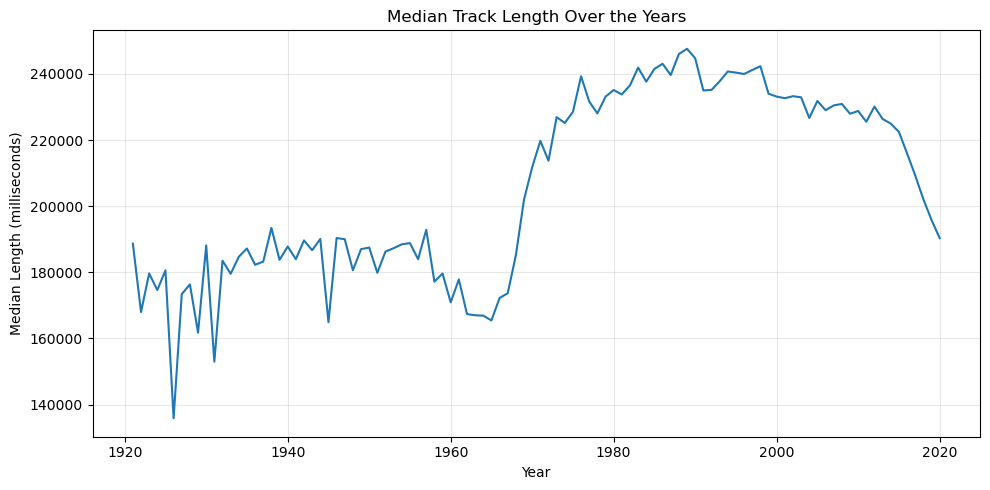

In [38]:
## Assignment. Line Plot and Scatter Plot (0.5 points): Creates both a line plot and a scatter plot with appropriate labels and titles.
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_duration_median['year'],
    yearly_duration_median['median_duration_ms'],
)

plt.title('Median Track Length Over the Years')
plt.xlabel('Year')
plt.ylabel('Median Length (milliseconds)')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

##### We can interestingly see that songs during 1920-1965 were a lot more shorter than they were ~1970-2015. However from 2015 -> 2020, the song lengths went down. Here we could ask if it has something to do with Tiktok.

### Scatterplot

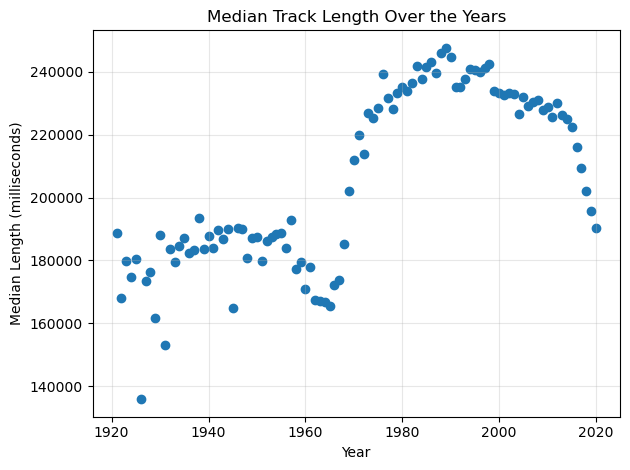

In [39]:
## Assignment. Line Plot and Scatter Plot (0.5 points): Creates both a line plot and a scatter plot with appropriate labels and titles.

plt.scatter(
    yearly_duration_median['year'],
    yearly_duration_median['median_duration_ms']
)

plt.title('Median Track Length Over the Years')
plt.xlabel('Year')
plt.ylabel('Median Length (milliseconds)')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Bar chart

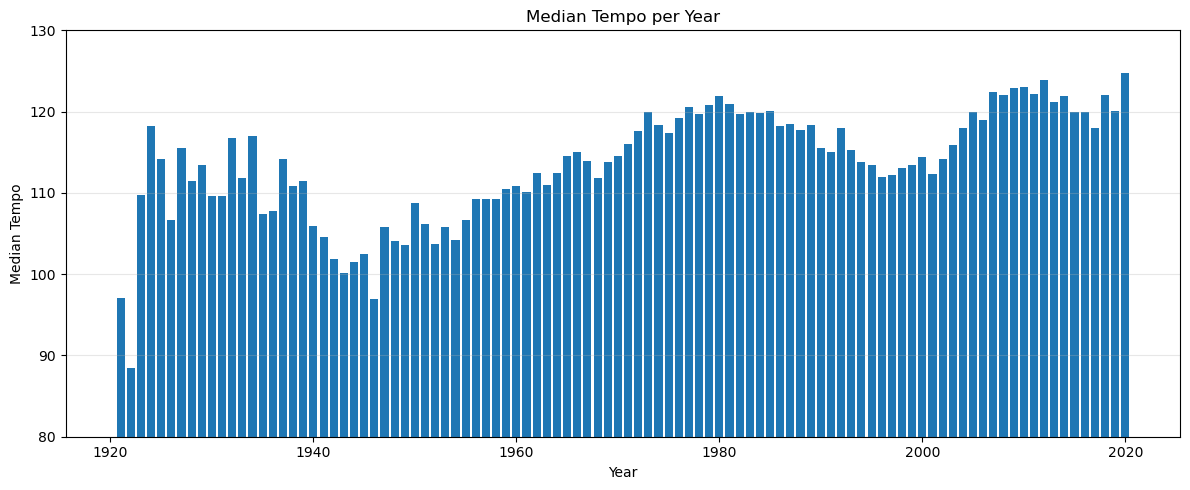

In [40]:
## Assignment. Bar Chart and Histogram (0.5 points)
plt.figure(figsize=(12, 5))
bars = plt.bar(
    yearly_tempo_median['year'],
    yearly_tempo_median['median_tempo'],
)

plt.title('Median Tempo per Year')
plt.xlabel('Year')
plt.ylabel('Median Tempo')
plt.ylim(80, 130)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Histogram

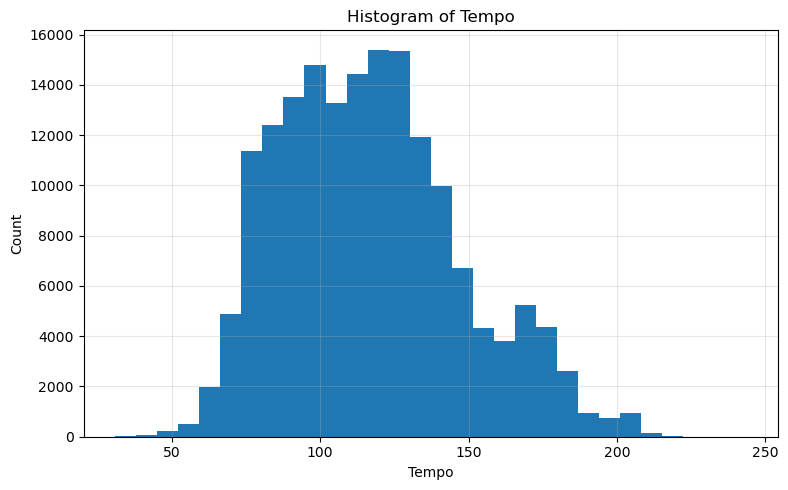

In [41]:
## Assignment. Bar Chart and Histogram (0.5 points)

plt.figure(figsize=(8, 5))
plt.hist(final_df['tempo'],
         bins=30,
)

plt.title(f'Histogram of Tempo')
plt.xlabel('Tempo')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Pie chart

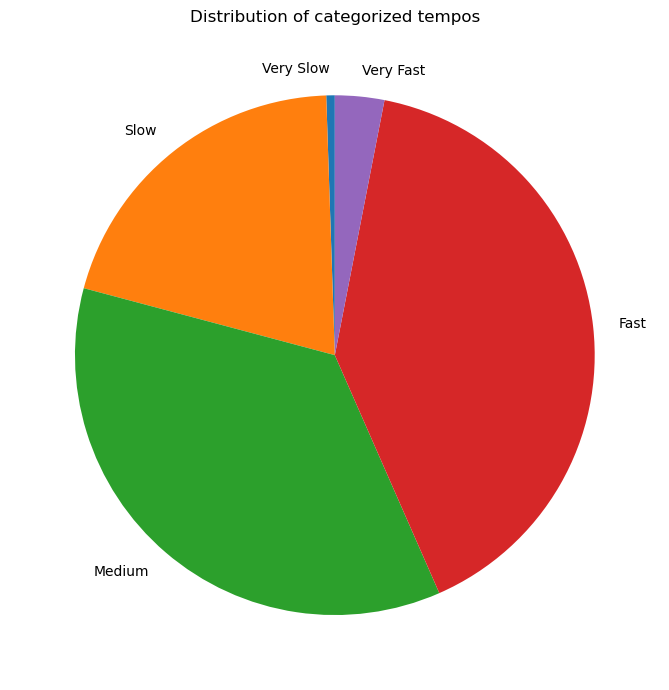

In [42]:
## Assignment. Pie Chart and Heatmap (0.5 points): Produces a pie chart and a heatmap.

# Let's use my tempocategory I created earlier
counts = final_df['tempocategory'].value_counts().sort_index()

plt.figure(figsize=(7, 7))
plt.pie(
    counts,
    labels=counts.index,
    startangle=90
)

plt.title(f'Distribution of categorized tempos')
plt.tight_layout()
plt.show()

### Heatmap

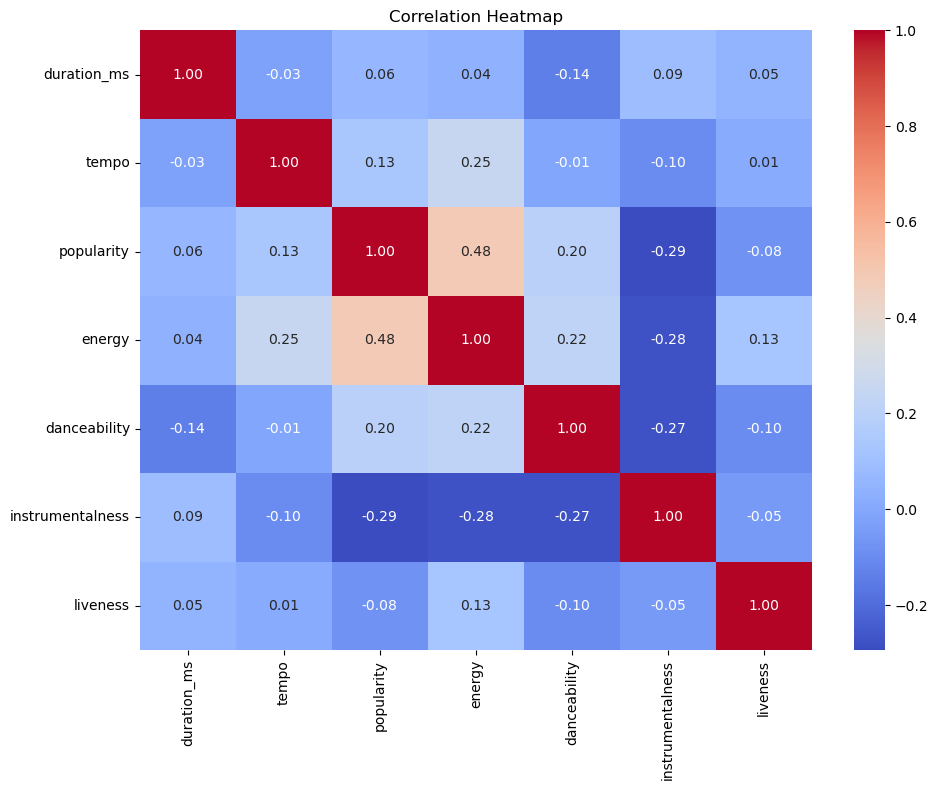

In [43]:
import seaborn as sns

## Assignment. Pie Chart and Heatmap (0.5 points): Produces a pie chart and a heatmap.

numeric_cols = [
    'duration_ms', 'tempo', 'popularity',
    'energy', 'danceability', 'instrumentalness', 'liveness'
]

numeric_df = final_df[numeric_cols]
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### 3D Map

In [44]:
## Assignment. 3D Plot (0.5 points): Creates a 3D plot if applicable to the dataset.
from mpl_toolkits.mplot3d import Axes3D

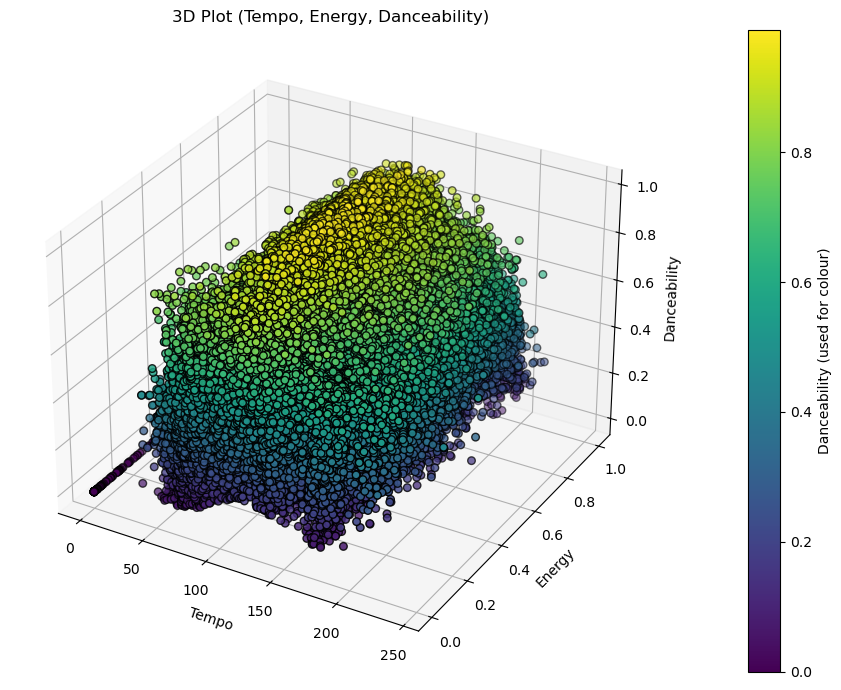

In [45]:
cols = ['tempo', 'energy', 'danceability']
data = df[cols]

x = data['tempo']
y = data['energy']
z = data['danceability']

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    x, y, z,
    c=z,
    s=30,
    edgecolor='k'
)

ax.set_xlabel('Tempo')
ax.set_ylabel('Energy')
ax.set_zlabel('Danceability')
ax.set_title('3D Plot (Tempo, Energy, Danceability)')

cbar = fig.colorbar(scatter, pad=0.1)
cbar.set_label('Danceability')

plt.tight_layout()
plt.show()

## 5 Some extra

##### I want to provide something extra on top of the provided assignments. Let's try to find out, how danceability has changed over the decades.

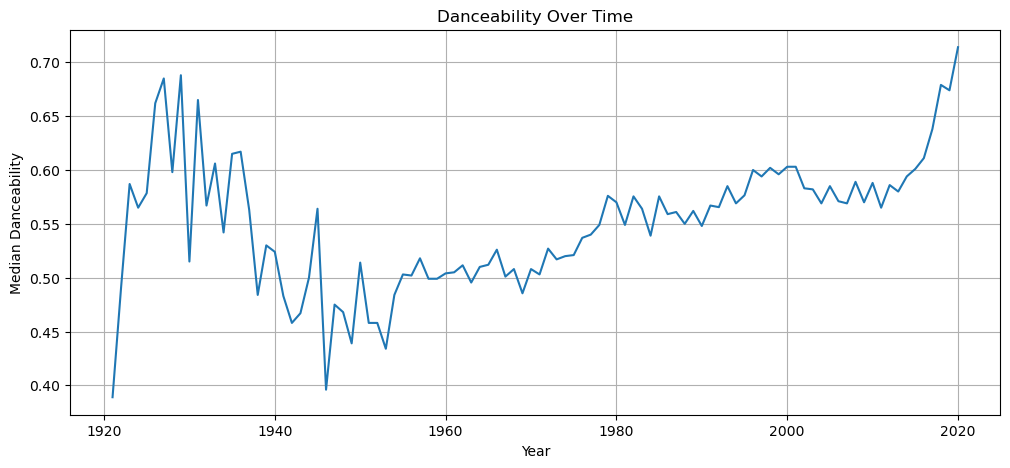

In [51]:
# Ensure release_year is numeric
final_df['year'] = pd.to_numeric(final_df['year'])

yearly = final_df.groupby('year')['danceability'].median().reset_index()

plt.figure(figsize=(12,5))
plt.plot(yearly['year'], yearly['danceability'])
plt.title('Danceability Over Time')
plt.xlabel('Year')
plt.ylabel('Median Danceability')
plt.grid(True)
plt.show()

##### Here we can see that there's peak in danceability around 1920-1930s and 2020. I'm thinking if WW2 had something to with massive drop between 1930-1940.